In [66]:
import torch
torch.set_grad_enabled(False)
import numpy as np
import argparse
from pathlib import Path
import sys, os
from omegaconf import OmegaConf
import matplotlib.pyplot as plt
import pandas as pd
from hydra.utils import instantiate
from dataclasses import dataclass, field

from shimnet.predict_utils import Defaults, resample_input_spectrum, resample_output_spectrum, initialize_predictor, get_model_ppm_per_point


# silent deprecation warnings
# https://github.com/pytorch/pytorch/issues/97207#issuecomment-1494781560
import warnings
warnings.filterwarnings('ignore', category=UserWarning, message='TypedStorage is deprecated')


### Settings

In [88]:
@dataclass
class Settings:
    peak_region_threshold: float = 0.001 # metrics will be calculated only on points where the optimal spectrum is above this threshold, with the largest peak being 1.0.
    label: str = field(init=False)
    save_results: bool = True
    output_parent_dir: Path = Path("evaluation_output")
    output_dir: Path = field(init=False)
    draw_plots: bool = True

    def __post_init__(self):
        # This runs automatically after the object is created
        self.label = f"relthr_{self.peak_region_threshold}"
        self.output_dir = self.output_parent_dir / self.label
        if self.save_results:
            self.output_dir.mkdir(parents=True, exist_ok=True)
        
settings = Settings(save_results=False, draw_plots=False)
if settings.save_results:
    print(f"Evaluation results will be saved to: {settings.output_dir}")
else:
    print(f"Evaluation results will NOT be saved to disk.")

Evaluation results will NOT be saved to disk.


## Initialize predictors

In [6]:
predictors_params = {
    "shimnetV1_600": {
        "config_path": "../configs/shimnet_600.yaml",
        "weights_path": "../weights/shimnet_600MHz.pt"
    },
    "shimnetV2_600": {
        "config_path": "../configs/shimnetV2_600.yaml",
        "weights_path": "../weights/shimnetV2_600MHz.pt"
    },
}

predictors = {}
for predictor_name, params in predictors_params.items():
    config = OmegaConf.load(params["config_path"])
    model_ppm_per_point = get_model_ppm_per_point(config)
    predictor = initialize_predictor(config, params["weights_path"])
    predictors[predictor_name] = {
        'config': config,
        'model_ppm_per_point': model_ppm_per_point,
        'predictor': predictor
    }


## Experimental spectra, shim coil responses

### Spectra loading

In [7]:
clean_experimental_spectra_data = {}
for clean_experimental_path in Path("../sample_data").glob("*bestshims*csv"):
    clean_spectrum_name = clean_experimental_path.stem
    clean_experimental_spectra_data[clean_spectrum_name] = {
        'path': clean_experimental_path,
        'input_spectrometer_frequency': float(clean_spectrum_name.split("_bestshims_")[-1][:-3]), # extract spectrometer frequency from filename, :-3 to remove "MHz"
        'is_reaction_monitoring': False
        }

for reaction_dir in Path("../sample_data/reaction_monitoring").iterdir():
    for shimmed_dir in reaction_dir.glob("*shimmed*"):
        for reaction_file in shimmed_dir.glob("*.csv"):
            clean_spectrum_name = f'{reaction_dir.stem}_{shimmed_dir.stem}_{reaction_file.stem}'        
            clean_experimental_spectra_data[clean_spectrum_name] = {
                'path': reaction_file,
                'input_spectrometer_frequency': 600,
                'is_reaction_monitoring': True
            }


### response functions

In [8]:
n_responses_to_use = 100
shim_coil_response_functions = {}

# responses used in ShimNet training
response_function_files_shimnet_v1 = ['../' + f for f in predictors["shimnetV1_600"]["config"].data.response_functions_files]
shim_coil_response_functions_all_shimnet_v1 = torch.cat([torch.load(f).squeeze() for f in response_function_files_shimnet_v1], dim=0)
shim_coil_response_functions['shiment_v1_600'] = shim_coil_response_functions_all_shimnet_v1[np.random.default_rng(seed=42).choice(shim_coil_response_functions_all_shimnet_v1.shape[0], size=n_responses_to_use, replace=False)]
del shim_coil_response_functions_all_shimnet_v1

# responses used in ShimNetV2 training
response_function_files_shimnet_v2 = ['../' + f for f in predictors["shimnetV2_600"]["config"].data.response_generator.response_function_library.response_files]
shim_coil_response_functions_all_shimnet_v2 = torch.cat([torch.load(f).squeeze() for f in response_function_files_shimnet_v2], dim=0)
shim_coil_response_functions['shiment_v2_600'] = shim_coil_response_functions_all_shimnet_v2[np.random.default_rng(seed=42).choice(shim_coil_response_functions_all_shimnet_v2.shape[0], size=n_responses_to_use, replace=False)]
del shim_coil_response_functions_all_shimnet_v2

/tmp/ipykernel_2129159/2837984030.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  shim_coil_response_functions_all_shimnet_v1 = torch.cat([torch.load(f).squeeze() for f 

###

### loop

In [87]:
def compute_metrics_for_batch(predictions, opti_spectrum, mask=None):
    opti_unfolded = torch.tile(opti_spectrum, (predictions.shape[0], 1)) # (n_predictions, n_points)
    if mask is not None:
        opti_unfolded[~mask] = 0
        predictions[~mask] = 0
    residual = predictions - opti_unfolded

    mae = residual.abs().mean().item()
    mse = (residual ** 2).mean().item()

    mae_normalized = mae / opti_spectrum.abs().mean().item()
    mse_normalized = mse / (opti_spectrum ** 2).mean().item()
    return mae, mse, mae_normalized, mse_normalized

In [ ]:
results = []
for clean_spectrum_name, clean_spectrum_info in clean_experimental_spectra_data.items():
    if clean_spectrum_info['input_spectrometer_frequency'] == 700:
        continue
    clean_spectrum_file = clean_spectrum_info['path']
    input_freqs_input_ppm, input_spectrum = np.loadtxt(clean_spectrum_file).T
    input_spectrum /= input_spectrum.max() # normalize spectrum to have max of 1

    input_spectrometer_frequency = clean_spectrum_info['input_spectrometer_frequency']

    for predictor_name, predictor_data in predictors.items():
        model_ppm_per_point = predictor_data['model_ppm_per_point']
        input_freqs_model_ppm = input_freqs_input_ppm * clean_spectrum_info['input_spectrometer_frequency'] / predictor_data['config'].metadata.spectrometer_frequency
        freqs, opti_spectrum = resample_input_spectrum(input_freqs_model_ppm, input_spectrum, model_ppm_per_point)

        peak_regions_mask_opti = opti_spectrum > settings.peak_region_threshold

        opti_spectrum = torch.from_numpy(opti_spectrum).float()
        opti_spectrum_sum = opti_spectrum.sum()
        opti_spectrum_sum_in_peak_regions = opti_spectrum[peak_regions_mask_opti].sum()
        opti_spectrum_squared_sum_in_peak_regions = (opti_spectrum[peak_regions_mask_opti] ** 2).sum()

        for response_function_name, response_functions in shim_coil_response_functions.items():
            print(f"Evaluating {clean_spectrum_name} with {predictor_name} and {response_function_name}...")
            input_spectra = torch.conv1d(opti_spectrum[None, None], response_functions[:, None], padding='same').squeeze() # (n_responses_to_use, n_points)
            # correct distortion function being not 1 sum
            input_spectra = input_spectra * opti_spectrum_sum / input_spectra.sum(dim=-1, keepdim=True)
            # scaling for the model usage range
            scaling_factor = Defaults.SCALE / input_spectra.max(dim=-1, keepdim=True).values
            input_spectra *= scaling_factor
            predictions = predictor_data['predictor'](input_spectra) / scaling_factor
            

            peak_regions_mask_predictions = (predictions > settings.peak_region_threshold) & torch.from_numpy(peak_regions_mask_opti)[None, :]
            mae, mse, mae_normalized, mse_normalized = compute_metrics_for_batch(predictions, opti_spectrum, mask=peak_regions_mask_predictions)

            results.append({
                'clean_spectrum_name': clean_spectrum_name,
                'predictor_name': predictor_name,
                'response_function_name': response_function_name,
                'is_reaction_monitoring': clean_spectrum_info['is_reaction_monitoring'],
                'MSE': mse,
                'MAE': mae,
                'MSE normalized': mse_normalized,
                'MAE normalized': mae_normalized,
                # 'opti_spectrum_sum': opti_spectrum_sum.item(),
                # 'opti_spectrum_squared_sum': opti_spectrum_squared_sum.item()
            })
            del predictions, input_spectra
results_df = pd.DataFrame(results)
if settings.save_results:
    results_df.to_csv(settings.output_dir / "evaluation_experimental_spectra_results.csv", index=False)
results_df


Evaluating Geraniol_bestshims_600MHz with shimnetV1_600 and shiment_v1_600...
Evaluating Geraniol_bestshims_600MHz with shimnetV1_600 and shiment_v2_600...
Evaluating Geraniol_bestshims_600MHz with shimnetV2_600 and shiment_v1_600...
Evaluating Geraniol_bestshims_600MHz with shimnetV2_600 and shiment_v2_600...
Evaluating CresolRed_cut_bestshims_600MHz with shimnetV1_600 and shiment_v1_600...
Evaluating CresolRed_cut_bestshims_600MHz with shimnetV1_600 and shiment_v2_600...
Evaluating CresolRed_cut_bestshims_600MHz with shimnetV2_600 and shiment_v1_600...
Evaluating CresolRed_cut_bestshims_600MHz with shimnetV2_600 and shiment_v2_600...
Evaluating CresolRed_bestshims_600MHz with shimnetV1_600 and shiment_v1_600...
Evaluating CresolRed_bestshims_600MHz with shimnetV1_600 and shiment_v2_600...
Evaluating CresolRed_bestshims_600MHz with shimnetV2_600 and shiment_v1_600...
Evaluating CresolRed_bestshims_600MHz with shimnetV2_600 and shiment_v2_600...
Evaluating mono-click_shimmed_spectra_hi

,clean_spectrum_name,predictor_name,response_function_name,is_reaction_monitoring,MSE,MAE,MSE normalized,MAE normalized
0,Geraniol_bestshims_600MHz,shimnetV1_600,shiment_v1_600,False,0.000004,0.000114,0.021182,0.118085
1,Geraniol_bestshims_600MHz,shimnetV1_600,shiment_v2_600,False,0.000005,0.000120,0.024816,0.124059
2,Geraniol_bestshims_600MHz,shimnetV2_600,shiment_v1_600,False,0.000003,0.000081,0.013348,0.083245
3,Geraniol_bestshims_600MHz,shimnetV2_600,shiment_v2_600,False,0.000003,0.000082,0.014820,0.084881
4,CresolRed_cut_bestshims_600MHz,shimnetV1_600,shiment_v1_600,False,0.000002,0.000069,0.009460,0.068171
5,CresolRed_cut_bestshims_600MHz,shimnetV1_600,shiment_v2_600,False,0.000003,0.000090,0.016814,0.089221
6,CresolRed_cut_bestshims_600MHz,shimnetV2_600,shiment_v1_600,False,0.000001,0.000061,0.006050,0.060356
7,CresolRed_cut_bestshims_600MHz,shimnetV2_600,shiment_v2_600,False,0.000002,0.000068,0.011273,0.067350
8,CresolRed_bestshims_600MHz,shimnetV1_600,shiment_v1_600,False,0.000001,0.000035,0.023535,0.147927
9,CresolRed_bestshims_600MHz,shimnetV1_600,shiment_v2_600,False,0.000004,0.000046,0.061929,0.196728


In [10]:
results_df.groupby(['predictor_name', 'response_function_name'])[['MSE normalized', 'MAE normalized']].mean()

MSE normalized  MAE normalized
predictor_name response_function_name                                
shimnetV1_600  shiment_v1_600                0.000001        0.000019
               shiment_v2_600                0.000002        0.000020
shimnetV2_600  shiment_v1_600                0.000001        0.000018
               shiment_v2_600                0.000001        0.000018

In [86]:
results_by_dataset

,clean_spectrum_name,response_function_name,is_reaction_monitoring,shimnetV1_600 MSE,shimnetV2_600 MSE,shimnetV1_600 MAE,shimnetV2_600 MAE,shimnetV1_600 MAE normalized,shimnetV2_600 MAE normalized,shimnetV1_600 MSE normalized,shimnetV2_600 MSE normalized,MAE_difference,MAE_difference_percentage,MSE_difference,MSE_difference_percentage,MAE normalized difference,MSE normalized difference,ShimNetV2 MAE prevalence,ShimNetV2 MSE prevalence
0,CresolRed_bestshims_600MHz,shiment_v1_600,False,0.000001,0.000004,0.000035,0.000045,0.147927,0.190361,0.023535,0.062522,0.042434,28.685883,0.038987,165.656593,0.042434,0.038987,0.0,0.0
1,CresolRed_bestshims_600MHz,shiment_v2_600,False,0.000004,0.000003,0.000046,0.000039,0.196728,0.166005,0.061929,0.051831,-0.030722,-15.616601,-0.010098,-16.305522,-0.030722,-0.010098,1.0,1.0
2,CresolRed_cut_bestshims_600MHz,shiment_v1_600,False,0.000002,0.000001,0.000069,0.000061,0.068171,0.060356,0.009460,0.006050,-0.007815,-11.464160,-0.003410,-36.044581,-0.007815,-0.003410,1.0,1.0
3,CresolRed_cut_bestshims_600MHz,shiment_v2_600,False,0.000003,0.000002,0.000090,0.000068,0.089221,0.067350,0.016814,0.011273,-0.021872,-24.513931,-0.005541,-32.953878,-0.021872,-0.005541,1.0,1.0
4,Geraniol_bestshims_600MHz,shiment_v1_600,False,0.000004,0.000003,0.000114,0.000081,0.118085,0.083245,0.021182,0.013348,-0.034840,-29.504042,-0.007834,-36.985784,-0.034840,-0.007834,1.0,1.0
5,Geraniol_bestshims_600MHz,shiment_v2_600,False,0.000005,0.000003,0.000120,0.000082,0.124059,0.084881,0.024816,0.014820,-0.039179,-31.580719,-0.009995,-40.278553,-0.039179,-0.009995,1.0,1.0
6,bis-click_shimmed_spectra_high_concentration_a...,shiment_v1_600,True,0.000024,0.000010,0.000722,0.000472,0.096375,0.062986,0.019230,0.008408,-0.033390,-34.645292,-0.010823,-56.279037,-0.033390,-0.010823,1.0,1.0
7,bis-click_shimmed_spectra_high_concentration_a...,shiment_v2_600,True,0.000018,0.000013,0.000665,0.000474,0.088704,0.063279,0.014419,0.010621,-0.025425,-28.662790,-0.003797,-26.335928,-0.025425,-0.003797,1.0,1.0
8,bis-click_shimmed_spectra_high_concentration_b...,shiment_v1_600,True,0.000028,0.000022,0.000589,0.000484,0.097982,0.080600,0.019663,0.015246,-0.017382,-17.740279,-0.004417,-22.464280,-0.017382,-0.004417,1.0,1.0
9,bis-click_shimmed_spectra_high_concentration_b...,shiment_v2_600,True,0.000024,0.000018,0.000567,0.000449,0.094459,0.074810,0.016656,0.012333,-0.019649,-20.801781,-0.004322,-25.950241,-0.019649,-0.004322,1.0,1.0


In [81]:
results_by_dataset = results_df.pivot(index=['clean_spectrum_name', 'response_function_name', 'is_reaction_monitoring'], columns='predictor_name', values=['MSE', 'MAE', 'MAE normalized', 'MSE normalized'])
# flatten the multiindex columns
results_by_dataset.columns = [f"{model} {metric}" for metric, model in results_by_dataset.columns]
results_by_dataset = results_by_dataset.reset_index()
results_by_dataset['MAE_difference'] = results_by_dataset['shimnetV2_600 MAE normalized'] - results_by_dataset['shimnetV1_600 MAE normalized']
results_by_dataset['MAE_difference_percentage'] = results_by_dataset['MAE_difference'] / results_by_dataset['shimnetV1_600 MAE normalized'] * 100
results_by_dataset['MSE_difference'] = results_by_dataset['shimnetV2_600 MSE normalized'] - results_by_dataset['shimnetV1_600 MSE normalized']
results_by_dataset['MSE_difference_percentage'] = results_by_dataset['MSE_difference'] / results_by_dataset['shimnetV1_600 MSE normalized'] * 100

results_by_dataset["MAE normalized difference"] = results_by_dataset["shimnetV2_600 MAE normalized"] - results_by_dataset["shimnetV1_600 MAE normalized"]
results_by_dataset["MSE normalized difference"] = results_by_dataset["shimnetV2_600 MSE normalized"] - results_by_dataset["shimnetV1_600 MSE normalized"]

results_by_dataset["ShimNetV2 MAE prevalence"] = (results_by_dataset["MAE_difference"] < 0).astype(float)
results_by_dataset["ShimNetV2 MSE prevalence"] = (results_by_dataset["MSE_difference"] < 0).astype(float)

if settings.save_results:
    results_by_dataset.to_csv(settings.output_dir / "evaluation_experimental_spectra_by_dataset.csv", index=False)

results_by_dataset.groupby("is_reaction_monitoring")[['MAE_difference_percentage', 'MSE_difference_percentage']].mean()

,MAE_difference_percentage,MSE_difference_percentage
is_reaction_monitoring,,
False,-13.998928,0.514713
True,-14.930281,-21.825983


In [82]:
results_by_dataset.groupby("is_reaction_monitoring")[['ShimNetV2 MAE prevalence', 'ShimNetV2 MSE prevalence']].mean()

,ShimNetV2 MAE prevalence,ShimNetV2 MSE prevalence
is_reaction_monitoring,,
False,0.833333,0.833333
True,0.937500,0.875000


## Experimental spectra, experimetnal response functions

In [17]:
from plotly import graph_objects as go

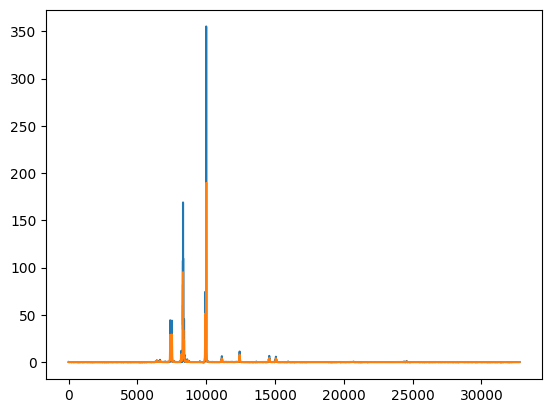

In [35]:
plt.plot(opti_spectrum)
plt.plot(disturbed_spectrum)


In [111]:
experimental_results = []
for spectra_file in Path("../../nmr-shim-data/created_disturbed_spectra").glob("*.csv"):
    if ("1-2-1" in spectra_file.stem) or "700MHz" in spectra_file.stem:
        continue
    print(f"Evaluating {spectra_file.stem}...")
    original_spectrum, disturbance = spectra_file.stem.split("_disturbed_")
    disturbance = disturbance.split("_response")[0]


    data = np.loadtxt(spectra_file, skiprows=1)
    freq, disturbed_spectrum, opti_spectrum = torch.from_numpy(data.T).float()
    opti_spectrum_sum = opti_spectrum.sum()
    disturbed_spectrum = disturbed_spectrum * opti_spectrum_sum/ disturbed_spectrum.sum()

    mask = (opti_spectrum > settings.peak_region_threshold) & (disturbed_spectrum > settings.peak_region_threshold)

    scale_factor = Defaults.SCALE / disturbed_spectrum.max()
    disturbed_spectrum_scaled = disturbed_spectrum * scale_factor

    if settings.draw_plots:
        fig = go.Figure()
        fig.add_trace(go.Scatter(x=freq, y=disturbed_spectrum, mode='lines', name='Disturbed Spectrum'))
        fig.add_trace(go.Scatter(x=freq, y=opti_spectrum, mode='lines', name='Optimal Spectrum'))
        fig.update_layout(title=f"Spectra for {spectra_file.stem}", xaxis_title="Frequency (ppm)", yaxis_title="Intensity (a.u.)")
        fig.update_xaxes(autorange="reversed")

    for predictor_name, predictor_data in predictors.items():
        corrected_spectrum = predictor_data['predictor'](disturbed_spectrum_scaled) / scale_factor

        mse = torch.nn.functional.mse_loss(corrected_spectrum[mask], opti_spectrum[mask]).item()
        mae = torch.nn.functional.l1_loss(corrected_spectrum[mask], opti_spectrum[mask]).item()
        mae_normalized = mae / opti_spectrum[mask].abs().mean().item()
        mse_normalized = mse / (opti_spectrum[mask]**2).mean().item()

        experimental_results.append({
            'clean_spectrum_name': spectra_file.stem,
            'original_spectrum': original_spectrum,
            'disturbance': disturbance,
            'predictor_name': predictor_name,
            'MSE': mse,
            'MAE': mae,
            'MAE normalized': mae_normalized,
            'MSE normalized': mse_normalized
        })

        # print(f"MSE: {mse}, MAE: {mae}")
        if settings.draw_plots:
            fig.add_trace(go.Scatter(x=freq, y=corrected_spectrum, mode='lines', name=f'Corrected {predictor_name}, MAE: {mae_normalized:.3e}, MSE: {mse_normalized:.3e}'))
    if settings.draw_plots:
        fig.write_html(settings.output_dir / f"evaluation_{spectra_file.stem}.html")


experimental_results_df = pd.DataFrame(experimental_results)

if settings.save_results:
    experimental_results_df.to_csv(settings.output_dir / "evaluation_output/evaluation_experimental_spectra_experimental_responses.csv", index=False)
experimental_results_df

Evaluating Azarone_besteshims_supressed_600MHz_disturbed_Geraniol_up_1mm_600MHz_response...
Evaluating Azarone_besteshims_supressed_600MHz_disturbed_Azarone_X_supressed_600MHz_response...
Evaluating CresolRed_cut_bestshims_600MHz_disturbed_Geraniol_up_1mm_600MHz_response...
Evaluating CresolRed_cut_bestshims_600MHz_disturbed_Azarone_X_supressed_600MHz_response...
Evaluating Geraniol_bestshims_600MHz_disturbed_Azarone_Z1Z2_supressed_600MHz_response...
Evaluating CresolRed_cut_bestshims_600MHz_disturbed_Azarone_Z1Z2_supressed_600MHz_response...
Evaluating Geraniol_bestshims_600MHz_disturbed_Geraniol_up_1mm_600MHz_response...
Evaluating Azarone_besteshims_supressed_600MHz_disturbed_Azarone_Z1Z2Z3Z4_supressed_600MHz_response...
Evaluating Geraniol_bestshims_600MHz_disturbed_Azarone_X_supressed_600MHz_response...
Evaluating Azarone_besteshims_supressed_600MHz_disturbed_CresolRed_after_styrene_cut_600MHz_response...
Evaluating CresolRed_cut_bestshims_600MHz_disturbed_Azarone_Z1Z2Z3Z4_supress

,clean_spectrum_name,original_spectrum,disturbance,predictor_name,MSE,MAE,MAE normalized,MSE normalized
0,Azarone_besteshims_supressed_600MHz_disturbed_...,Azarone_besteshims_supressed_600MHz,Geraniol_up_1mm_600MHz,shimnetV1_600,3.350929,0.168004,0.392066,0.128614
1,Azarone_besteshims_supressed_600MHz_disturbed_...,Azarone_besteshims_supressed_600MHz,Geraniol_up_1mm_600MHz,shimnetV2_600,6.840668,0.215587,0.503109,0.262555
2,Azarone_besteshims_supressed_600MHz_disturbed_...,Azarone_besteshims_supressed_600MHz,Azarone_X_supressed_600MHz,shimnetV1_600,1.032503,0.100731,0.223844,0.037545
3,Azarone_besteshims_supressed_600MHz_disturbed_...,Azarone_besteshims_supressed_600MHz,Azarone_X_supressed_600MHz,shimnetV2_600,0.751862,0.092750,0.206108,0.027340
4,CresolRed_cut_bestshims_600MHz_disturbed_Geran...,CresolRed_cut_bestshims_600MHz,Geraniol_up_1mm_600MHz,shimnetV1_600,86468.921875,41.578465,0.331953,0.057765
5,CresolRed_cut_bestshims_600MHz_disturbed_Geran...,CresolRed_cut_bestshims_600MHz,Geraniol_up_1mm_600MHz,shimnetV2_600,77272.117188,43.654198,0.348526,0.051621
6,CresolRed_cut_bestshims_600MHz_disturbed_Azaro...,CresolRed_cut_bestshims_600MHz,Azarone_X_supressed_600MHz,shimnetV1_600,10438.121094,23.588196,0.170983,0.006127
7,CresolRed_cut_bestshims_600MHz_disturbed_Azaro...,CresolRed_cut_bestshims_600MHz,Azarone_X_supressed_600MHz,shimnetV2_600,5936.027832,21.925173,0.158929,0.003484
8,Geraniol_bestshims_600MHz_disturbed_Azarone_Z1...,Geraniol_bestshims_600MHz,Azarone_Z1Z2_supressed_600MHz,shimnetV1_600,3.049143,0.160952,0.186338,0.047379
9,Geraniol_bestshims_600MHz_disturbed_Azarone_Z1...,Geraniol_bestshims_600MHz,Azarone_Z1Z2_supressed_600MHz,shimnetV2_600,3.869188,0.197509,0.228660,0.060121


In [112]:
experimental_results_df.groupby('predictor_name')[['MSE normalized', 'MAE normalized']].mean()

,MSE normalized,MAE normalized
predictor_name,,
shimnetV1_600,0.051742,0.266344
shimnetV2_600,0.096279,0.297388


In [114]:
experimental_results_by_dataset = experimental_results_df.pivot(index=['clean_spectrum_name', 'original_spectrum', 'disturbance'], columns='predictor_name', values=['MSE', 'MAE', 'MSE normalized', 'MAE normalized'])
experimental_results_by_dataset.columns = [f"{model} {metric}" for metric, model in experimental_results_by_dataset.columns]
experimental_results_by_dataset = experimental_results_by_dataset.reset_index()
experimental_results_by_dataset['MAE_difference'] = experimental_results_by_dataset['shimnetV2_600 MAE normalized'] - experimental_results_by_dataset['shimnetV1_600 MAE normalized']
experimental_results_by_dataset['MAE_difference_percentage'] = experimental_results_by_dataset['MAE_difference'] / experimental_results_by_dataset['shimnetV1_600 MAE normalized'] * 100   
experimental_results_by_dataset['MSE_difference'] = experimental_results_by_dataset['shimnetV2_600 MSE normalized'] - experimental_results_by_dataset['shimnetV1_600 MSE normalized']
experimental_results_by_dataset['MSE_difference_percentage'] = experimental_results_by_dataset['MSE_difference'] / experimental_results_by_dataset['shimnetV1_600 MSE normalized'] * 100

# experimental_results_by_dataset[["original_spectrum", 'disturbance']] = experimental_results_by_dataset['clean_spectrum_name'].str.split('_disturbed_', expand=True)

if settings.save_results:
    experimental_results_by_dataset.to_csv(settings.output_dir / "evaluation_output/evaluation_experimental_spectra_experimental_responses_by_dataset.csv", index=False)

experimental_results_by_dataset

,clean_spectrum_name,original_spectrum,disturbance,shimnetV1_600 MSE,shimnetV2_600 MSE,shimnetV1_600 MAE,shimnetV2_600 MAE,shimnetV1_600 MSE normalized,shimnetV2_600 MSE normalized,shimnetV1_600 MAE normalized,shimnetV2_600 MAE normalized,MAE_difference,MAE_difference_percentage,MSE_difference,MSE_difference_percentage
0,Azarone_besteshims_supressed_600MHz_disturbed_...,Azarone_besteshims_supressed_600MHz,Azarone_X_supressed_600MHz,1.032503,0.751862,0.100731,0.092750,0.037545,0.027340,0.223844,0.206108,-0.017736,-7.923499,-0.010205,-27.180646
1,Azarone_besteshims_supressed_600MHz_disturbed_...,Azarone_besteshims_supressed_600MHz,Azarone_Z1Z2Z3Z4_supressed_600MHz,0.486645,0.898103,0.086020,0.101529,0.018559,0.034251,0.199119,0.235019,0.035900,18.029544,0.015692,84.549907
2,Azarone_besteshims_supressed_600MHz_disturbed_...,Azarone_besteshims_supressed_600MHz,Azarone_Z1Z2_supressed_600MHz,2.038446,2.649836,0.131606,0.140420,0.080461,0.104593,0.314257,0.335304,0.021047,6.697455,0.024133,29.992964
3,Azarone_besteshims_supressed_600MHz_disturbed_...,Azarone_besteshims_supressed_600MHz,CresolRed_after_styrene_cut_600MHz,2.646778,11.553986,0.169690,0.287323,0.108280,0.472674,0.418817,0.709151,0.290334,69.322357,0.364394,336.530194
4,Azarone_besteshims_supressed_600MHz_disturbed_...,Azarone_besteshims_supressed_600MHz,Geraniol_up_1mm_600MHz,3.350929,6.840668,0.168004,0.215587,0.128614,0.262555,0.392066,0.503109,0.111043,28.322418,0.133941,104.142467
5,CresolRed_cut_bestshims_600MHz_disturbed_Azaro...,CresolRed_cut_bestshims_600MHz,Azarone_X_supressed_600MHz,10438.121094,5936.027832,23.588196,21.925173,0.006127,0.003484,0.170983,0.158929,-0.012055,-7.050234,-0.002643,-43.131261
6,CresolRed_cut_bestshims_600MHz_disturbed_Azaro...,CresolRed_cut_bestshims_600MHz,Azarone_Z1Z2Z3Z4_supressed_600MHz,24611.474609,8282.495117,26.922554,24.922712,0.017320,0.005829,0.224714,0.208022,-0.016692,-7.428128,-0.011492,-66.347018
7,CresolRed_cut_bestshims_600MHz_disturbed_Azaro...,CresolRed_cut_bestshims_600MHz,Azarone_Z1Z2_supressed_600MHz,27185.361328,58083.539062,29.940071,35.494320,0.019752,0.042202,0.256275,0.303817,0.047542,18.551221,0.022450,113.657411
8,CresolRed_cut_bestshims_600MHz_disturbed_Creso...,CresolRed_cut_bestshims_600MHz,CresolRed_after_styrene_cut_600MHz,62436.265625,87972.523438,44.916767,42.184467,0.051022,0.071889,0.420093,0.394539,-0.025554,-6.083029,0.020868,40.899720
9,CresolRed_cut_bestshims_600MHz_disturbed_Geran...,CresolRed_cut_bestshims_600MHz,Geraniol_up_1mm_600MHz,86468.921875,77272.117188,41.578465,43.654198,0.057765,0.051621,0.331953,0.348526,0.016572,4.992328,-0.006144,-10.635965


In [115]:
experimental_results_by_dataset.groupby('original_spectrum')[['MAE_difference_percentage', 'MSE_difference_percentage']].mean()

,MAE_difference_percentage,MSE_difference_percentage
original_spectrum,,
Azarone_besteshims_supressed_600MHz,22.889655,105.606977
CresolRed_cut_bestshims_600MHz,0.596432,6.888577
Geraniol_bestshims_600MHz,-3.840155,10.795996


In [116]:
experimental_results_by_dataset.groupby('disturbance')[['MAE_difference_percentage', 'MSE_difference_percentage']].mean()

,MAE_difference_percentage,MSE_difference_percentage
disturbance,,
Azarone_X_supressed_600MHz,-21.640973,-52.835053
Azarone_Z1Z2Z3Z4_supressed_600MHz,-4.233769,-14.820969
Azarone_Z1Z2_supressed_600MHz,15.987212,56.848220
CresolRed_after_styrene_cut_600MHz,21.393248,153.282916
Geraniol_up_1mm_600MHz,21.237502,63.010804


### smoothed kernels

In [117]:
experimental_results = []
for spectra_file in Path("../../nmr-shim-data/created_disturbed_spectra").glob("*.csv"):
    if ("1-2-1" not in spectra_file.stem) or "700MHz" in spectra_file.stem:
        continue
    print(f"Evaluating {spectra_file.stem}...")
    original_spectrum, disturbance = spectra_file.stem.split("_disturbed_")
    disturbance = disturbance.split("_response")[0]


    data = np.loadtxt(spectra_file, skiprows=1)
    freq, disturbed_spectrum, opti_spectrum = torch.from_numpy(data.T).float()
    opti_spectrum_sum = opti_spectrum.sum()
    disturbed_spectrum = disturbed_spectrum * opti_spectrum_sum/ disturbed_spectrum.sum()

    mask = (opti_spectrum > settings.peak_region_threshold) & (disturbed_spectrum > settings.peak_region_threshold)

    scale_factor = Defaults.SCALE / disturbed_spectrum.max()
    disturbed_spectrum_scaled = disturbed_spectrum * scale_factor

    if settings.draw_plots:
        fig = go.Figure()
        fig.add_trace(go.Scatter(x=freq, y=disturbed_spectrum, mode='lines', name='Disturbed Spectrum'))
        fig.add_trace(go.Scatter(x=freq, y=opti_spectrum, mode='lines', name='Optimal Spectrum'))
        fig.update_layout(title=f"Spectra for {spectra_file.stem}", xaxis_title="Frequency (ppm)", yaxis_title="Intensity (a.u.)")
        fig.update_xaxes(autorange="reversed")

    for predictor_name, predictor_data in predictors.items():
        corrected_spectrum = predictor_data['predictor'](disturbed_spectrum_scaled) / scale_factor

        mse = torch.nn.functional.mse_loss(corrected_spectrum[mask], opti_spectrum[mask]).item()
        mae = torch.nn.functional.l1_loss(corrected_spectrum[mask], opti_spectrum[mask]).item()
        mae_normalized = mae / opti_spectrum[mask].abs().mean().item()
        mse_normalized = mse / (opti_spectrum[mask]**2).mean().item()

        experimental_results.append({
            'clean_spectrum_name': spectra_file.stem,
            'original_spectrum': original_spectrum,
            'disturbance': disturbance,
            'predictor_name': predictor_name,
            'MSE': mse,
            'MAE': mae,
            'MAE normalized': mae_normalized,
            'MSE normalized': mse_normalized
        })

        # print(f"MSE: {mse}, MAE: {mae}")
        if settings.draw_plots:
            fig.add_trace(go.Scatter(x=freq, y=corrected_spectrum, mode='lines', name=f'Corrected {predictor_name}, MAE: {mae_normalized:.3e}, MSE: {mse_normalized:.3e}'))
    if settings.draw_plots:
        fig.write_html(settings.output_dir / f"evaluation_{spectra_file.stem}.html")


experimental_results_df = pd.DataFrame(experimental_results)

if settings.save_results:
    experimental_results_df.to_csv(settings.output_dir / "evaluation_output/evaluation_experimental_spectra_experimental_responses_smoothed.csv", index=False)
experimental_results_df

Evaluating Geraniol_bestshims_600MHz_disturbed_Geraniol_up_1mm_600MHz_response_smoothing_1-2-1...
Evaluating CresolRed_cut_bestshims_600MHz_disturbed_Azarone_Z1Z2Z3Z4_supressed_600MHz_response_smoothing_1-2-1...
Evaluating Azarone_besteshims_supressed_600MHz_disturbed_Azarone_Z1Z2Z3Z4_supressed_600MHz_response_smoothing_1-2-1...
Evaluating Geraniol_bestshims_600MHz_disturbed_CresolRed_after_styrene_cut_600MHz_response_smoothing_1-2-1...
Evaluating CresolRed_cut_bestshims_600MHz_disturbed_CresolRed_after_styrene_cut_600MHz_response_smoothing_1-2-1...
Evaluating Geraniol_bestshims_600MHz_disturbed_Azarone_Z1Z2_supressed_600MHz_response_smoothing_1-2-1...
Evaluating Azarone_besteshims_supressed_600MHz_disturbed_Geraniol_up_1mm_600MHz_response_smoothing_1-2-1...
Evaluating Azarone_besteshims_supressed_600MHz_disturbed_Azarone_X_supressed_600MHz_response_smoothing_1-2-1...
Evaluating CresolRed_cut_bestshims_600MHz_disturbed_Azarone_Z1Z2_supressed_600MHz_response_smoothing_1-2-1...
Evaluatin

,clean_spectrum_name,original_spectrum,disturbance,predictor_name,MSE,MAE,MAE normalized,MSE normalized
0,Geraniol_bestshims_600MHz_disturbed_Geraniol_u...,Geraniol_bestshims_600MHz,Geraniol_up_1mm_600MHz,shimnetV1_600,6.472361,0.254192,0.252967,0.086142
1,Geraniol_bestshims_600MHz_disturbed_Geraniol_u...,Geraniol_bestshims_600MHz,Geraniol_up_1mm_600MHz,shimnetV2_600,9.698577,0.297077,0.295645,0.129081
2,CresolRed_cut_bestshims_600MHz_disturbed_Azaro...,CresolRed_cut_bestshims_600MHz,Azarone_Z1Z2Z3Z4_supressed_600MHz,shimnetV1_600,26830.201172,27.593031,0.238127,0.019820
3,CresolRed_cut_bestshims_600MHz_disturbed_Azaro...,CresolRed_cut_bestshims_600MHz,Azarone_Z1Z2Z3Z4_supressed_600MHz,shimnetV2_600,11068.087891,25.694550,0.221743,0.008176
4,Azarone_besteshims_supressed_600MHz_disturbed_...,Azarone_besteshims_supressed_600MHz,Azarone_Z1Z2Z3Z4_supressed_600MHz,shimnetV1_600,0.666107,0.095378,0.225657,0.026016
5,Azarone_besteshims_supressed_600MHz_disturbed_...,Azarone_besteshims_supressed_600MHz,Azarone_Z1Z2Z3Z4_supressed_600MHz,shimnetV2_600,0.543972,0.082974,0.196310,0.021246
6,Geraniol_bestshims_600MHz_disturbed_CresolRed_...,Geraniol_bestshims_600MHz,CresolRed_after_styrene_cut_600MHz,shimnetV1_600,4.370850,0.273624,0.303240,0.064962
7,Geraniol_bestshims_600MHz_disturbed_CresolRed_...,Geraniol_bestshims_600MHz,CresolRed_after_styrene_cut_600MHz,shimnetV2_600,6.435675,0.257458,0.285324,0.095651
8,CresolRed_cut_bestshims_600MHz_disturbed_Creso...,CresolRed_cut_bestshims_600MHz,CresolRed_after_styrene_cut_600MHz,shimnetV1_600,62446.238281,44.654514,0.388597,0.046521
9,CresolRed_cut_bestshims_600MHz_disturbed_Creso...,CresolRed_cut_bestshims_600MHz,CresolRed_after_styrene_cut_600MHz,shimnetV2_600,107726.531250,44.336147,0.385827,0.080253


In [118]:
experimental_results_by_dataset = experimental_results_df.pivot(index=['clean_spectrum_name', 'original_spectrum', 'disturbance'], columns='predictor_name', values=['MSE', 'MAE', 'MSE normalized', 'MAE normalized'])
experimental_results_by_dataset.columns = [f"{model} {metric}" for metric, model in experimental_results_by_dataset.columns]
experimental_results_by_dataset = experimental_results_by_dataset.reset_index()
experimental_results_by_dataset['MAE_difference'] = experimental_results_by_dataset['shimnetV2_600 MAE normalized'] - experimental_results_by_dataset['shimnetV1_600 MAE normalized']
experimental_results_by_dataset['MAE_difference_percentage'] = experimental_results_by_dataset['MAE_difference'] / experimental_results_by_dataset['shimnetV1_600 MAE normalized'] * 100   
experimental_results_by_dataset['MSE_difference'] = experimental_results_by_dataset['shimnetV2_600 MSE normalized'] - experimental_results_by_dataset['shimnetV1_600 MSE normalized']
experimental_results_by_dataset['MSE_difference_percentage'] = experimental_results_by_dataset['MSE_difference'] / experimental_results_by_dataset['shimnetV1_600 MSE normalized'] * 100

# experimental_results_by_dataset[["original_spectrum", 'disturbance']] = experimental_results_by_dataset['clean_spectrum_name'].str.split('_disturbed_', expand=True)

if settings.save_results:
    experimental_results_by_dataset.to_csv(settings.output_dir / "evaluation_output/evaluation_experimental_spectra_experimental_responses_by_dataset_smoothed.csv", index=False)

experimental_results_by_dataset.groupby('original_spectrum')[['MAE_difference_percentage', 'MSE_difference_percentage']].mean()

,MAE_difference_percentage,MSE_difference_percentage
original_spectrum,,
Azarone_besteshims_supressed_600MHz,13.059019,62.477820
CresolRed_cut_bestshims_600MHz,-1.400017,15.022894
Geraniol_bestshims_600MHz,-6.496672,-0.829166


In [119]:
experimental_results_by_dataset.groupby('disturbance')[['MAE_difference_percentage', 'MSE_difference_percentage']].mean()

,MAE_difference_percentage,MSE_difference_percentage
disturbance,,
Azarone_X_supressed_600MHz,-20.663395,-50.500348
Azarone_Z1Z2Z3Z4_supressed_600MHz,-13.942324,-46.621514
Azarone_Z1Z2_supressed_600MHz,17.542595,75.563946
CresolRed_after_styrene_cut_600MHz,18.835268,131.876435
Geraniol_up_1mm_600MHz,6.831739,17.467396


## Training data

In [120]:
from omegaconf import OmegaConf

In [121]:
data_paths = {
    "shimnetV1_600": {
        "clean_spectra": "../data/sample_training_data/theoretical_spectrum.pt",
        "noised_spectra": "../data/sample_training_data/noised_spectrum.pt"
     },
     "shimnetV2_600": {
        "clean_spectra": "../data/sample_training_data/theoretical_spectrum_shimnetV2_shimnetV2_600.pt",
        "noised_spectra": "../data/sample_training_data/noised_spectrum_shimnetV2_shimnetV2_600.pt"
     }
}

models = {
      "shimnetV1_600": initialize_predictor(OmegaConf.load(predictors_params["shimnetV1_600"]["config_path"]), predictors_params["shimnetV1_600"]["weights_path"]).model.eval(),
      "shimnetV2_600": initialize_predictor(OmegaConf.load(predictors_params["shimnetV2_600"]["config_path"]), predictors_params["shimnetV2_600"]["weights_path"]).model.eval()
}


In [123]:
predictions.shape

torch.Size([1000, 1, 2048])

In [125]:
clean_spectra.sum(dim=-1, keepdim=True)

tensor([[[63.3602]],

        [[53.5892]],

        [[52.4697]],

        ...,

        [[35.3659]],

        [[45.3960]],

        [[29.4904]]])

In [126]:
torch.nn.functional.mse_loss(predictions, clean_spectra).shape

/tmp/ipykernel_2129159/1621936843.py:1: UserWarning: Using a target size (torch.Size([1024, 1, 2048])) that is different to the input size (torch.Size([1000, 1, 2048])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  torch.nn.functional.mse_loss(predictions, clean_spectra).shape


RuntimeError: The size of tensor a (1000) must match the size of tensor b (1024) at non-singleton dimension 0

In [127]:
        clean_spectra = torch.load(training_data_paths["clean_spectra"])
        noised_spectra = torch.load(training_data_paths["noised_spectra"])


/tmp/ipykernel_2129159/2964388280.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  clean_spectra = torch.load(training_data_paths["clean_spectra"])
/tmp/ipykernel_2129159

In [128]:
        predictions = predictor_data["predictor"].model(noised_spectra)['denoised']


In [131]:
?torch.nn.functional.mse_loss

Signature:
torch.nn.functional.mse_loss(
    input: torch.Tensor,
    target: torch.Tensor,
    size_average: Optional[bool] = None,
    reduce: Optional[bool] = None,
    reduction: str = 'mean',
) -> torch.Tensor
Docstring:
mse_loss(input, target, size_average=None, reduce=None, reduction='mean') -> Tensor

Measures the element-wise mean squared error.
See :class:`~torch.nn.MSELoss` for details.
File:      ~/miniconda3/envs/shimnetcpugui/lib/python3.10/site-packages/torch/nn/functional.py
Type:      function

In [134]:
torch.nn.functional.mse_loss(predictions, clean_spectra, reduction='none').mean(dim=-1).squeeze().shape

torch.Size([1024])

In [137]:
(clean_spectra ** 2).mean(dim=-1).squeeze().shape

torch.Size([1024])

In [138]:
synthetic_data_results = []
for predictor_name, predictor_data in predictors.items():
    for training_data_name, training_data_paths in data_paths.items():
        clean_spectra = torch.load(training_data_paths["clean_spectra"])
        noised_spectra = torch.load(training_data_paths["noised_spectra"])
        
        predictions = predictor_data["predictor"].model(noised_spectra)['denoised']

        mae_by_spectrum = torch.nn.functional.l1_loss(predictions, clean_spectra, reduction='none').mean(dim=-1).squeeze()
        mse_by_spectrum = torch.nn.functional.mse_loss(predictions, clean_spectra, reduction='none').mean(dim=-1).squeeze()


        synthetic_data_results.append({
            'training_data_name': training_data_name,
            'predictor_name': predictor_name,
            'MSE': mse_by_spectrum.mean().item(),
            'MAE': mae_by_spectrum.mean().item(),
            'MSE normalized': (mse_by_spectrum / (clean_spectra ** 2).mean(dim=-1).squeeze()).mean().item(),
            'MAE normalized': (mae_by_spectrum / clean_spectra.abs().mean(dim=-1).squeeze()).mean().item()
        })
synthetic_results_df = pd.DataFrame(synthetic_data_results)
synthetic_results_df

/tmp/ipykernel_2129159/2305965174.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  clean_spectra = torch.load(training_data_paths["clean_spectra"])
/tmp/ipykernel_2129159

,training_data_name,predictor_name,MSE,MAE,MSE normalized,MAE normalized
0,shimnetV1_600,shimnetV1_600,0.001005,0.005284,0.016138,0.207204
1,shimnetV2_600,shimnetV1_600,0.003690,0.009008,0.069806,0.315577
2,shimnetV1_600,shimnetV2_600,0.000783,0.003725,0.021089,0.131251
3,shimnetV2_600,shimnetV2_600,0.000958,0.003972,0.022076,0.132617


In [139]:
synthetic_results_by_dataset = synthetic_results_df.pivot(index='training_data_name', columns='predictor_name', values=['MSE normalized', 'MAE normalized'])
# flatten the multiindex columns
synthetic_results_by_dataset.columns = [f"{model} {metric}" for metric, model in synthetic_results_by_dataset.columns]
synthetic_results_by_dataset = synthetic_results_by_dataset.reset_index()
# synthetic_results_by_dataset
synthetic_results_by_dataset['MAE_difference'] = synthetic_results_by_dataset['shimnetV2_600 MAE normalized'] - synthetic_results_by_dataset['shimnetV1_600 MAE normalized']
synthetic_results_by_dataset['MSE_difference'] = synthetic_results_by_dataset['shimnetV2_600 MSE normalized'] - synthetic_results_by_dataset['shimnetV1_600 MSE normalized']
synthetic_results_by_dataset['MAE_difference_percentage'] = synthetic_results_by_dataset['MAE_difference'] / synthetic_results_by_dataset['shimnetV1_600 MAE normalized'] * 100
synthetic_results_by_dataset['MSE_difference_percentage'] = synthetic_results_by_dataset['MSE_difference'] / synthetic_results_by_dataset['shimnetV1_600 MSE normalized'] * 100

if settings.save_results:
    synthetic_results_by_dataset.to_csv(settings.output_dir / "evaluation_output/smoothed_kernels/evaluation_synthetic_results_by_dataset.csv", index=False)

synthetic_results_by_dataset

,training_data_name,shimnetV1_600 MSE normalized,shimnetV2_600 MSE normalized,shimnetV1_600 MAE normalized,shimnetV2_600 MAE normalized,MAE_difference,MSE_difference,MAE_difference_percentage,MSE_difference_percentage
0,shimnetV1_600,0.016138,0.021089,0.207204,0.131251,-0.075953,0.004952,-36.655937,30.682922
1,shimnetV2_600,0.069806,0.022076,0.315577,0.132617,-0.182960,-0.047730,-57.976252,-68.374804
